## Boundary Coherence Ablation on IP-Adapter / SD1.5

Re-runs the three boundary coherence strategies from the NST ablation
but now on the diffusion backbone.

Based on the recent feedback , the NST result may only reflect how NST uses features.
In a diffusion model, cross-attention is the actual spatial control mechanism,
so the ranking may change here.

Three strategies:
- Baseline: sequential inpainting, no harmonisation
- Approach 1: feathered blend (post-processing)
- Approach 2: AdaIN boundary alignment (post-processing)
- Approach 3: attention mask routing during generation


In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'


In [2]:
import json, requests, gc
import numpy as np
import cv2
import torch
from PIL import Image
from io import BytesIO
from datetime import datetime
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

OUT_DIR = os.path.expanduser('~/mllm_style_transfer/boundary_ablation/outputs')
WT_DIR  = os.path.expanduser('~/mllm_style_transfer/ip_adapter/weights')
os.makedirs(OUT_DIR, exist_ok=True)


def make_boundary_band(mask, band_px=15):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
    return cv2.subtract(cv2.dilate(mask, k), cv2.erode(mask, k))


def boundary_band_lpips(lpips_fn, original, stylised, mask, band_px=15):
    band = make_boundary_band(mask, band_px)
    bt = torch.from_numpy((band > 127).astype(np.float32)).to(DEVICE)
    def to_t(img):
        arr = np.array(img.convert('RGB')).astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE) * bt
    with torch.no_grad():
        return lpips_fn(to_t(original), to_t(stylised)).item()


def overlay_band(img, band, color=(255, 255, 0)):
    arr = np.array(img.convert('RGB')).copy()
    arr[band > 127] = color
    return Image.fromarray(arr)


print('helpers ready')


device: cuda
GPU: NVIDIA GeForce RTX 2080
GPU free: 8.0 GB
helpers ready


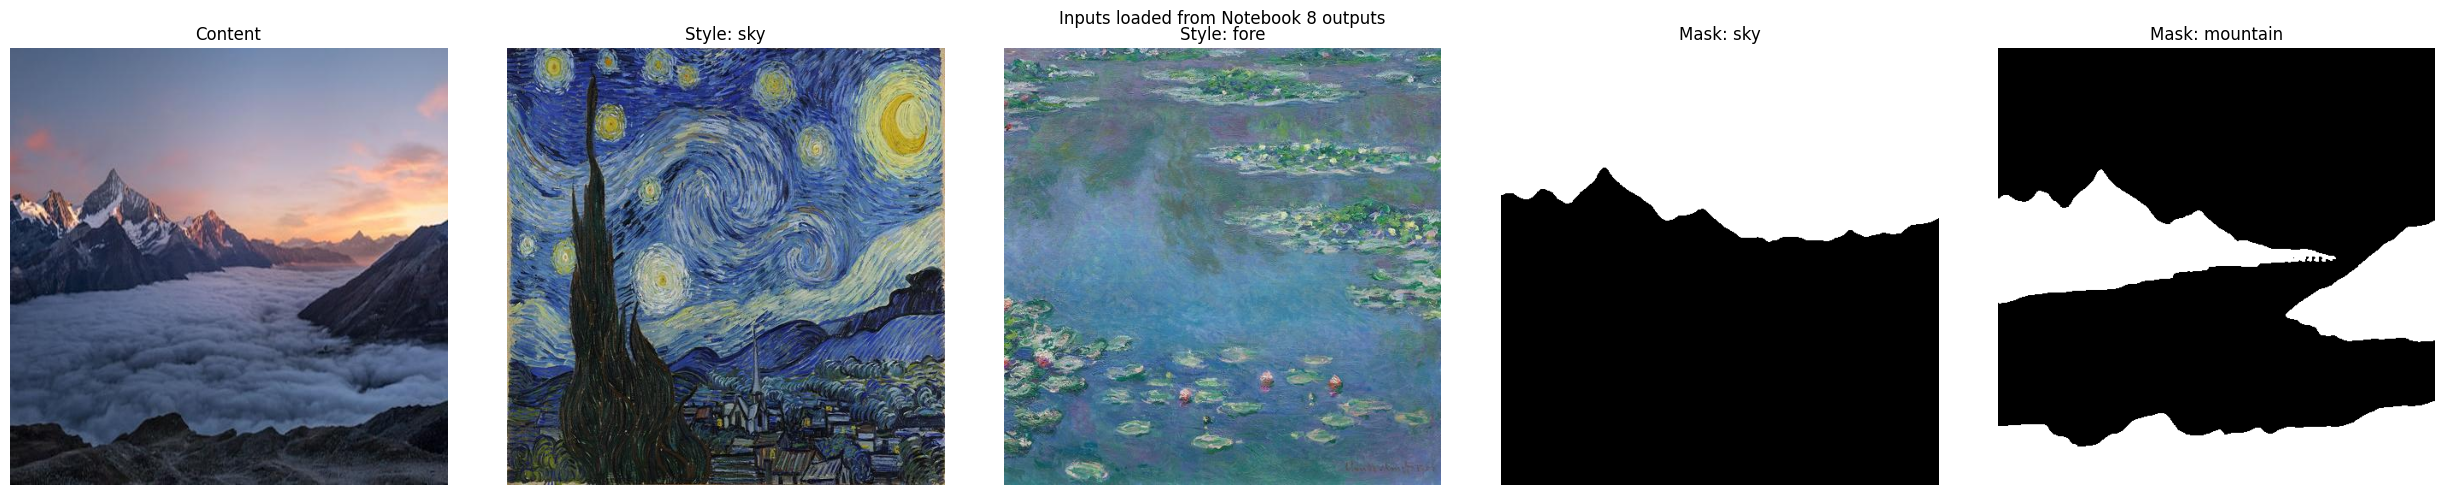

inputs ready


In [3]:
# load inputs from notebook 8 outputs so we test on the same content and styles
PREV_OUT = os.path.expanduser('~/mllm_style_transfer/ip_adapter/outputs')

content= Image.open(f'{PREV_OUT}/content.jpg').convert('RGB')
style_sky  = Image.open(f'{PREV_OUT}/style_vangogh.jpg').convert('RGB')
style_fore = Image.open(f'{PREV_OUT}/style_monet.jpg').convert('RGB')
mask_sky= np.array(Image.open(f'{PREV_OUT}/mask_sky.png').convert('L'))
mask_fore= np.array(Image.open(f'{PREV_OUT}/mask_fore.png').convert('L'))

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(content);axes[0].set_title('Content');axes[0].axis('off')
axes[1].imshow(style_sky);axes[1].set_title('Style: sky');axes[1].axis('off')
axes[2].imshow(style_fore);axes[2].set_title('Style: fore');axes[2].axis('off')
axes[3].imshow(mask_sky,  cmap='gray');axes[3].set_title('Mask: sky');axes[3].axis('off')
axes[4].imshow(mask_fore, cmap='gray');axes[4].set_title('Mask: mountain'); axes[4].axis('off')
plt.suptitle('Inputs loaded from Notebook 8 outputs', fontsize=12)
plt.tight_layout()
plt.show()
print('inputs ready')


In [4]:
from diffusers import StableDiffusionInpaintPipeline
from ip_adapter import IPAdapter

print('loading SD1.5-Inpainting...')
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    'runwayml/stable-diffusion-inpainting',
    torch_dtype=torch.float16,
    safety_checker=None,
    cache_dir=WT_DIR,
).to(DEVICE)
print(f'SD1.5 loaded | GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

ip_ckpt = f'{WT_DIR}/ip-adapter_sd15.bin'
ip_model = IPAdapter(
    sd_pipe=pipe,
    image_encoder_path='laion/CLIP-ViT-H-14-laion2B-s32B-b79K',
    ip_ckpt=ip_ckpt,
    device=DEVICE,
)
print(f'IP-Adapter loaded | GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')


def inpaint_region(content_img, mask_arr, style_ref_img,
                   prompt='artistic style painting',
                   num_steps=30, guidance_scale=7.5, ip_scale=0.5):
    mask_pil = Image.fromarray(mask_arr).convert('L')
    result = ip_model.generate(
        pil_image=style_ref_img,
        prompt=prompt,
        negative_prompt='ugly, blurry, distorted, watermark',
        image=content_img,
        mask_image=mask_pil,
        num_samples=1,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        scale=ip_scale,
    )
    return result[0]


print('pipeline ready')


loading SD1.5-Inpainting...


vae/diffusion_pytorch_model.safetensors not found


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/homes/rkr44/.local/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
An error occurred while trying to fetch /homes/rkr44/mllm_style_transfer/ip_adapter/weights/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /homes/rkr44/mllm_style_transfer/ip_adapter/weights/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /homes/rkr44/mllm_style_transfer/ip_adapter/wei

SD1.5 loaded | GPU free: 5.8 GB
IP-Adapter loaded | GPU free: 4.4 GB
pipeline ready


running baseline (no boundary coherence)...


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

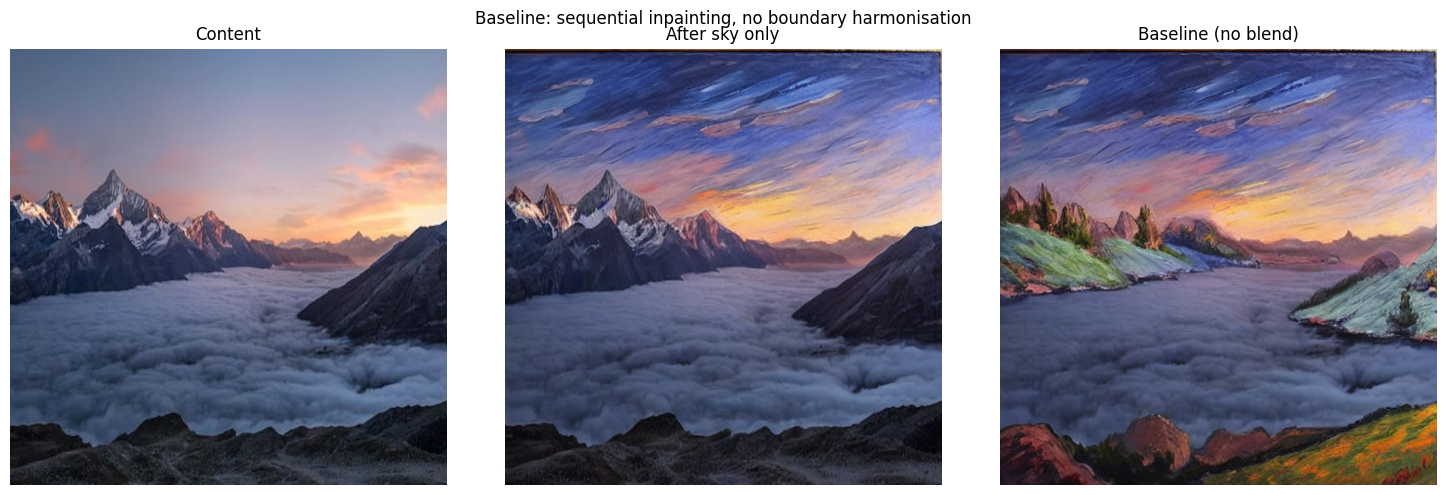

baseline done


In [5]:
# run the base multi-region inpainting with no boundary strategy applied
print('running baseline (no boundary coherence)...')

result_sky = inpaint_region(
    content_img=content,
    mask_arr=mask_sky,
    style_ref_img=style_sky,
    prompt='sky painted in impressionist style, oil painting',
    ip_scale=0.5,
)

result_base = inpaint_region(
    content_img=result_sky,
    mask_arr=mask_fore,
    style_ref_img=style_fore,
    prompt='mountains landscape impressionist painting style',
    ip_scale=0.5,
)
result_base.save(f'{OUT_DIR}/baseline_no_coherence.png')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(content);axes[0].set_title('Content');axes[0].axis('off')
axes[1].imshow(result_sky);axes[1].set_title('After sky only');axes[1].axis('off')
axes[2].imshow(result_base);axes[2].set_title('Baseline (no blend)'); axes[2].axis('off')
plt.suptitle('Baseline: sequential inpainting, no boundary harmonisation', fontsize=12)
plt.tight_layout()
plt.show()
print('baseline done')


approach 1: feathered blend...


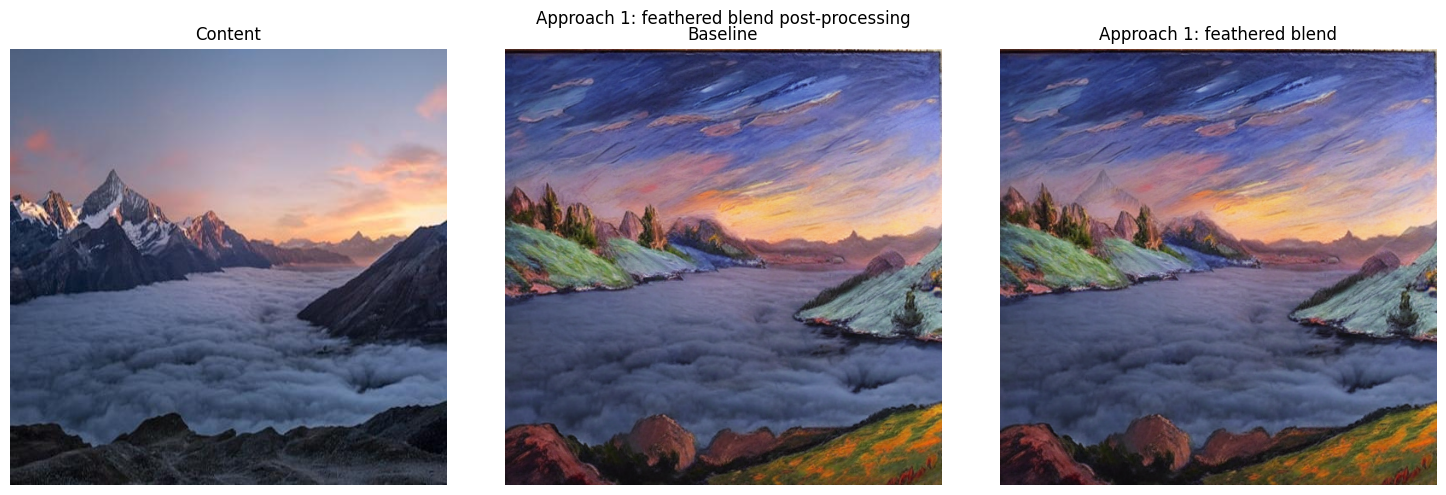

done


In [6]:
# Approach 1: feathered blend
# post-process the inpainted output by blending the boundary zone with original content
#  on NST, checking whether it helps on diffusion outputs too

def feathered_blend(result_img, content_img, mask1, mask2, band_px=20):
    result_arr  = np.array(result_img.convert('RGB')).astype(np.float32)
    content_arr = np.array(content_img.convert('RGB')).astype(np.float32)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
    band = cv2.bitwise_and(cv2.dilate(mask1, k), cv2.dilate(mask2, k))
    dist = cv2.distanceTransform(band, cv2.DIST_L2, 5)
    if dist.max() > 0:
        dist = dist / dist.max()
    alpha = (dist * 0.5)[..., np.newaxis]
    return Image.fromarray((result_arr*(1-alpha)+content_arr*alpha).clip(0,255).astype(np.uint8))


print('approach 1: feathered blend...')
result_a1 = feathered_blend(result_base, content, mask_sky, mask_fore, band_px=20)
result_a1.save(f'{OUT_DIR}/approach1_feathered.png')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(content);axes[0].set_title('Content');axes[0].axis('off')
axes[1].imshow(result_base); axes[1].set_title('Baseline');axes[1].axis('off')
axes[2].imshow(result_a1);axes[2].set_title('Approach 1: feathered blend'); axes[2].axis('off')
plt.suptitle('Approach 1: feathered blend post-processing', fontsize=12)
plt.tight_layout()
plt.show()
print('done')


approach 2: AdaIN alignment...


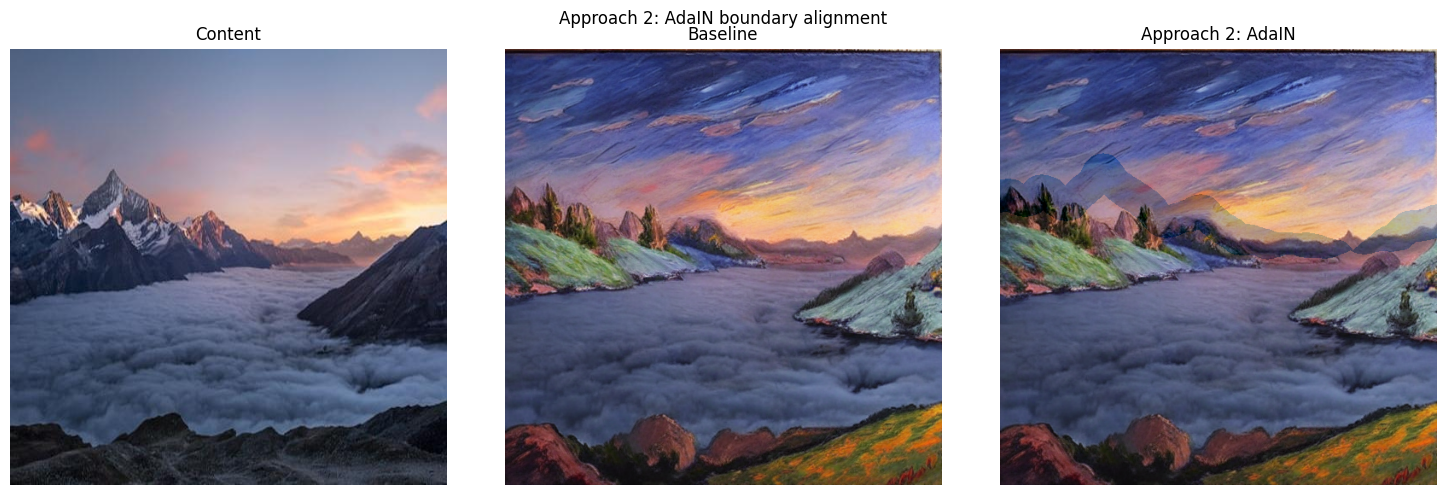

done


In [7]:
# Approach 2: AdaIN boundary alignment
# normalise colour stats of boundary pixels to the average of adjacent styled regions

def adain_blend(result_img, mask1, mask2, band_px=20):
    result_arr = np.array(result_img.convert('RGB')).astype(np.float32)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
    band = cv2.bitwise_and(cv2.dilate(mask1, k), cv2.dilate(mask2, k))
    if band.sum() == 0:
        return result_img
    def stats(arr, mask):
        px = arr[mask > 127]
        return px.mean(axis=0), px.std(axis=0)
    m1, s1 = stats(result_arr, cv2.bitwise_and(mask1, cv2.bitwise_not(band)))
    m2, s2 = stats(result_arr, cv2.bitwise_and(mask2, cv2.bitwise_not(band)))
    tm, ts = (m1+m2)/2, (s1+s2)/2
    bp = result_arr[band > 127]
    sm, ss = bp.mean(axis=0), bp.std(axis=0)+1e-6
    result_arr[band > 127] = ((bp-sm)/ss*ts+tm).clip(0, 255)
    return Image.fromarray(result_arr.astype(np.uint8))


print('approach 2: AdaIN alignment...')
result_a2 = adain_blend(result_base, mask_sky, mask_fore, band_px=20)
result_a2.save(f'{OUT_DIR}/approach2_adain.png')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(content);axes[0].set_title('Content');axes[0].axis('off')
axes[1].imshow(result_base); axes[1].set_title('Baseline');axes[1].axis('off')
axes[2].imshow(result_a2);axes[2].set_title('Approach 2: AdaIN'); axes[2].axis('off')
plt.suptitle('Approach 2: AdaIN boundary alignment', fontsize=12)
plt.tight_layout()
plt.show()
print('done')


approach 3: attention mask routing at boundary...


  0%|          | 0/20 [00:00<?, ?it/s]

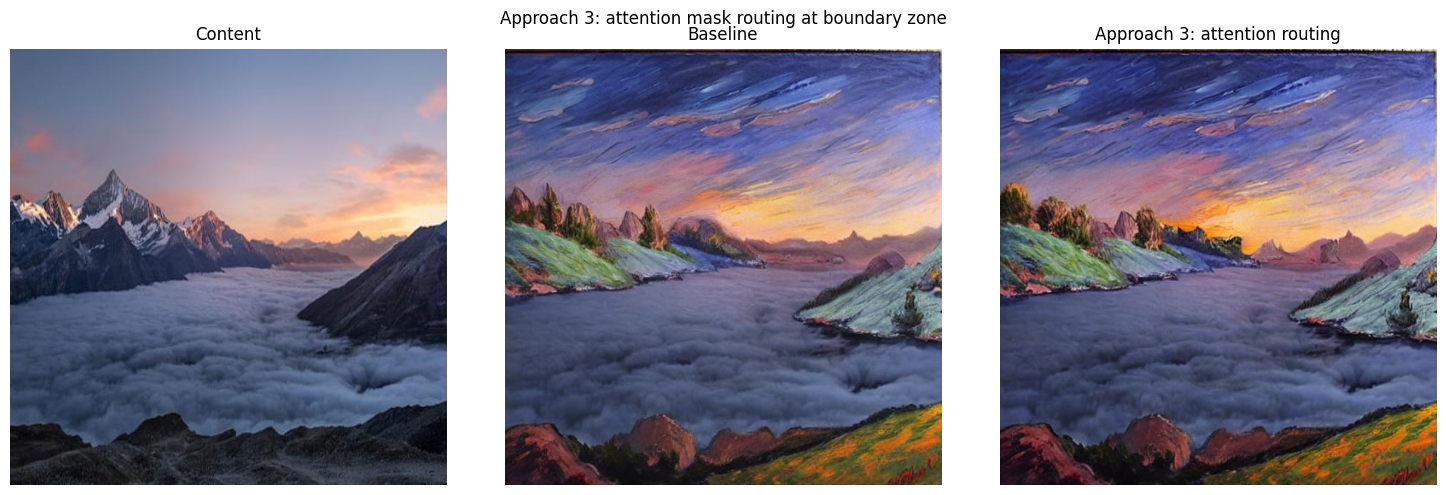

done


In [8]:
# Approach 3: attention mask routing during generation
# run a second inpainting pass over just the boundary band pixels
# conditioned on a blended style reference, this is the diffusion-native
# version of cross-attention boundary injection, using the inpainting mask
# to route attention to the transition zone rather than the full image

def get_boundary_mask(mask1, mask2, band_px=20):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (band_px*2+1, band_px*2+1))
    return cv2.bitwise_and(cv2.dilate(mask1, k), cv2.dilate(mask2, k))


def attention_boundary_inpaint(result_img, content_img, mask1, mask2,
                                style1, style2, band_px=20, ip_scale=0.4):
    band = get_boundary_mask(mask1, mask2, band_px)
    if band.sum() == 0:
        print('no boundary band found')
        return result_img
    s1_arr = np.array(style1.convert('RGB')).astype(np.float32)
    s2_arr = np.array(style2.convert('RGB')).astype(np.float32)
    blended_style = Image.fromarray(((s1_arr+s2_arr)/2).astype(np.uint8))
    result = ip_model.generate(
        pil_image=blended_style,
        prompt='smooth style transition, impressionist oil painting',
        negative_prompt='hard edge, seam, ugly, blurry',
        image=result_img,
        mask_image=Image.fromarray(band).convert('L'),
        num_samples=1,
        num_inference_steps=20,
        guidance_scale=7.5,
        scale=ip_scale,
    )
    return result[0]


print('approach 3: attention mask routing at boundary...')
result_a3 = attention_boundary_inpaint(
    result_img=result_base,
    content_img=content,
    mask1=mask_sky,
    mask2=mask_fore,
    style1=style_sky,
    style2=style_fore,
    band_px=20,
    ip_scale=0.4,
)
result_a3.save(f'{OUT_DIR}/approach3_attention_routing.png')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(content);axes[0].set_title('Content');axes[0].axis('off')
axes[1].imshow(result_base); axes[1].set_title('Baseline');axes[1].axis('off')
axes[2].imshow(result_a3);axes[2].set_title('Approach 3: attention routing');  axes[2].axis('off')
plt.suptitle('Approach 3: attention mask routing at boundary zone', fontsize=12)
plt.tight_layout()
plt.show()
print('done')


In [13]:
import lpips
lpips_fn = lpips.LPIPS(net='alex').to(DEVICE)

variants = [
    ('Baseline (no coherence)',result_base),
    ('Approach 1: feathered blend',result_a1),
    ('Approach 2: AdaIN alignment',result_a2),
    ('Approach 3: attention routing', result_a3),
]

print(f'\n{"="*65}')
print(f'  BOUNDARY COHERENCE ABLATION: IP-Adapter / SD1.5')
print(f'{"="*65}')
print(f'{"Strategy":<35} {"LPIPS (sky)":>12} {"vs Baseline"}')
print(f'{"-"*60}')

baseline_score = None
results = []

for name, img in variants:
    score = boundary_band_lpips(lpips_fn, content, img, mask_sky)
    if baseline_score is None:
        baseline_score = score
        delta_str = '-'
    else:
        delta = baseline_score - score
        delta_str = f'{delta:+.4f} {"better" if delta > 0 else "worse"}'
    print(f'  {name:<35} {score:>12.4f}  {delta_str}')
    results.append({'strategy': name, 'boundary_lpips': round(score, 4)})

print(f'{"="*65}')
print()
print('NST ablation for comparison:')
print('Baseline (NST):0.0678')
print('Feathered blend:0.0529  (+22% better)')
print('AdaIN:0.0705  (worse)')
print('Cross-attn (NST):0.0713  (worse)')


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /homes/rkr44/.local/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth

  BOUNDARY COHERENCE ABLATION: IP-Adapter / SD1.5
Strategy                             LPIPS (sky) vs Baseline
------------------------------------------------------------
  Baseline (no coherence)                   0.0439  -
  Approach 1: feathered blend               0.0366  +0.0073 better
  Approach 2: AdaIN alignment               0.0526  -0.0087 worse
  Approach 3: attention routing             0.0554  -0.0115 worse

NST ablation for comparison:
Baseline (NST):0.0678
Feathered blend:0.0529  (+22% better)
AdaIN:0.0705  (worse)
Cross-attn (NST):0.0713  (worse)


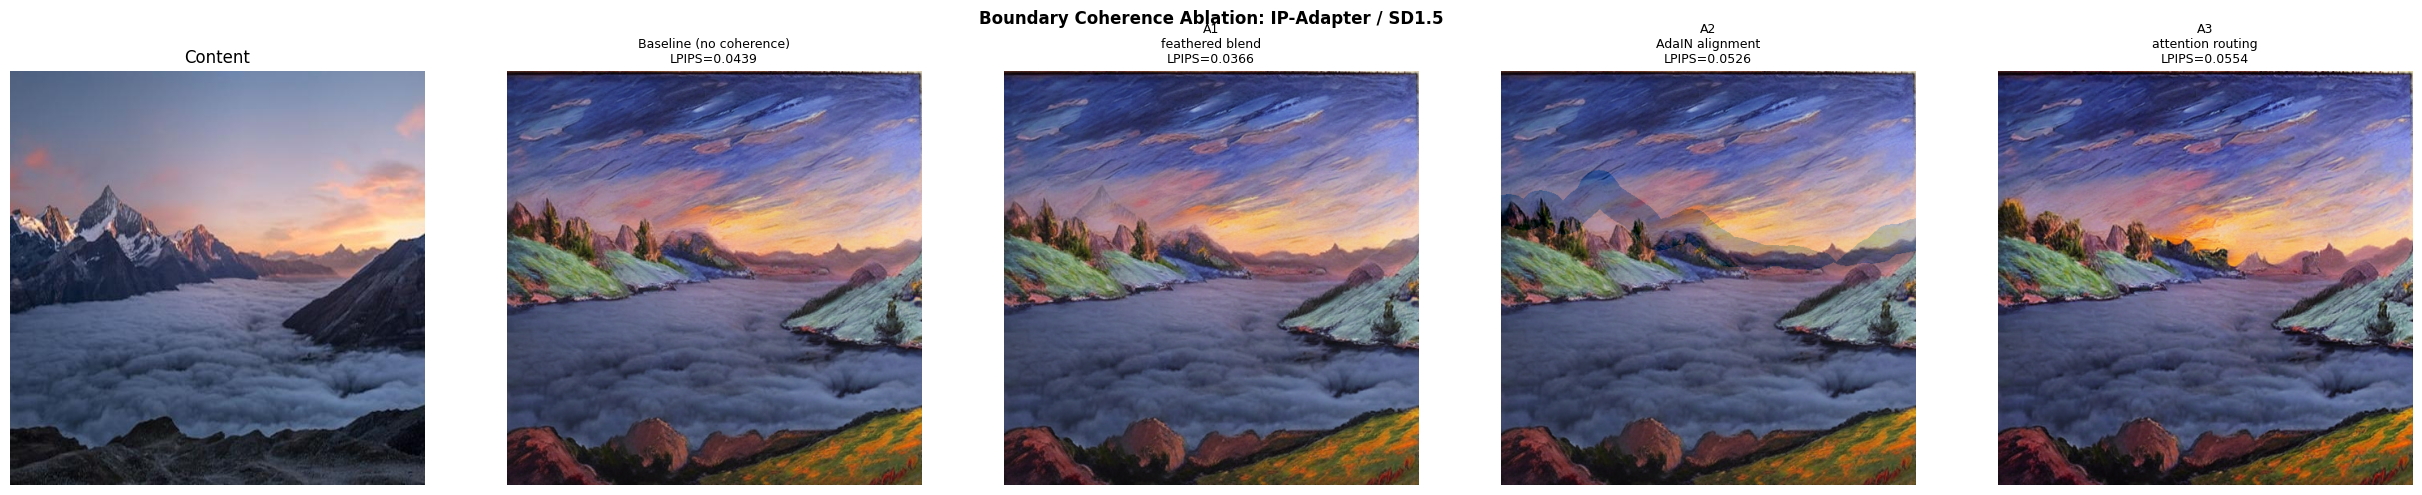

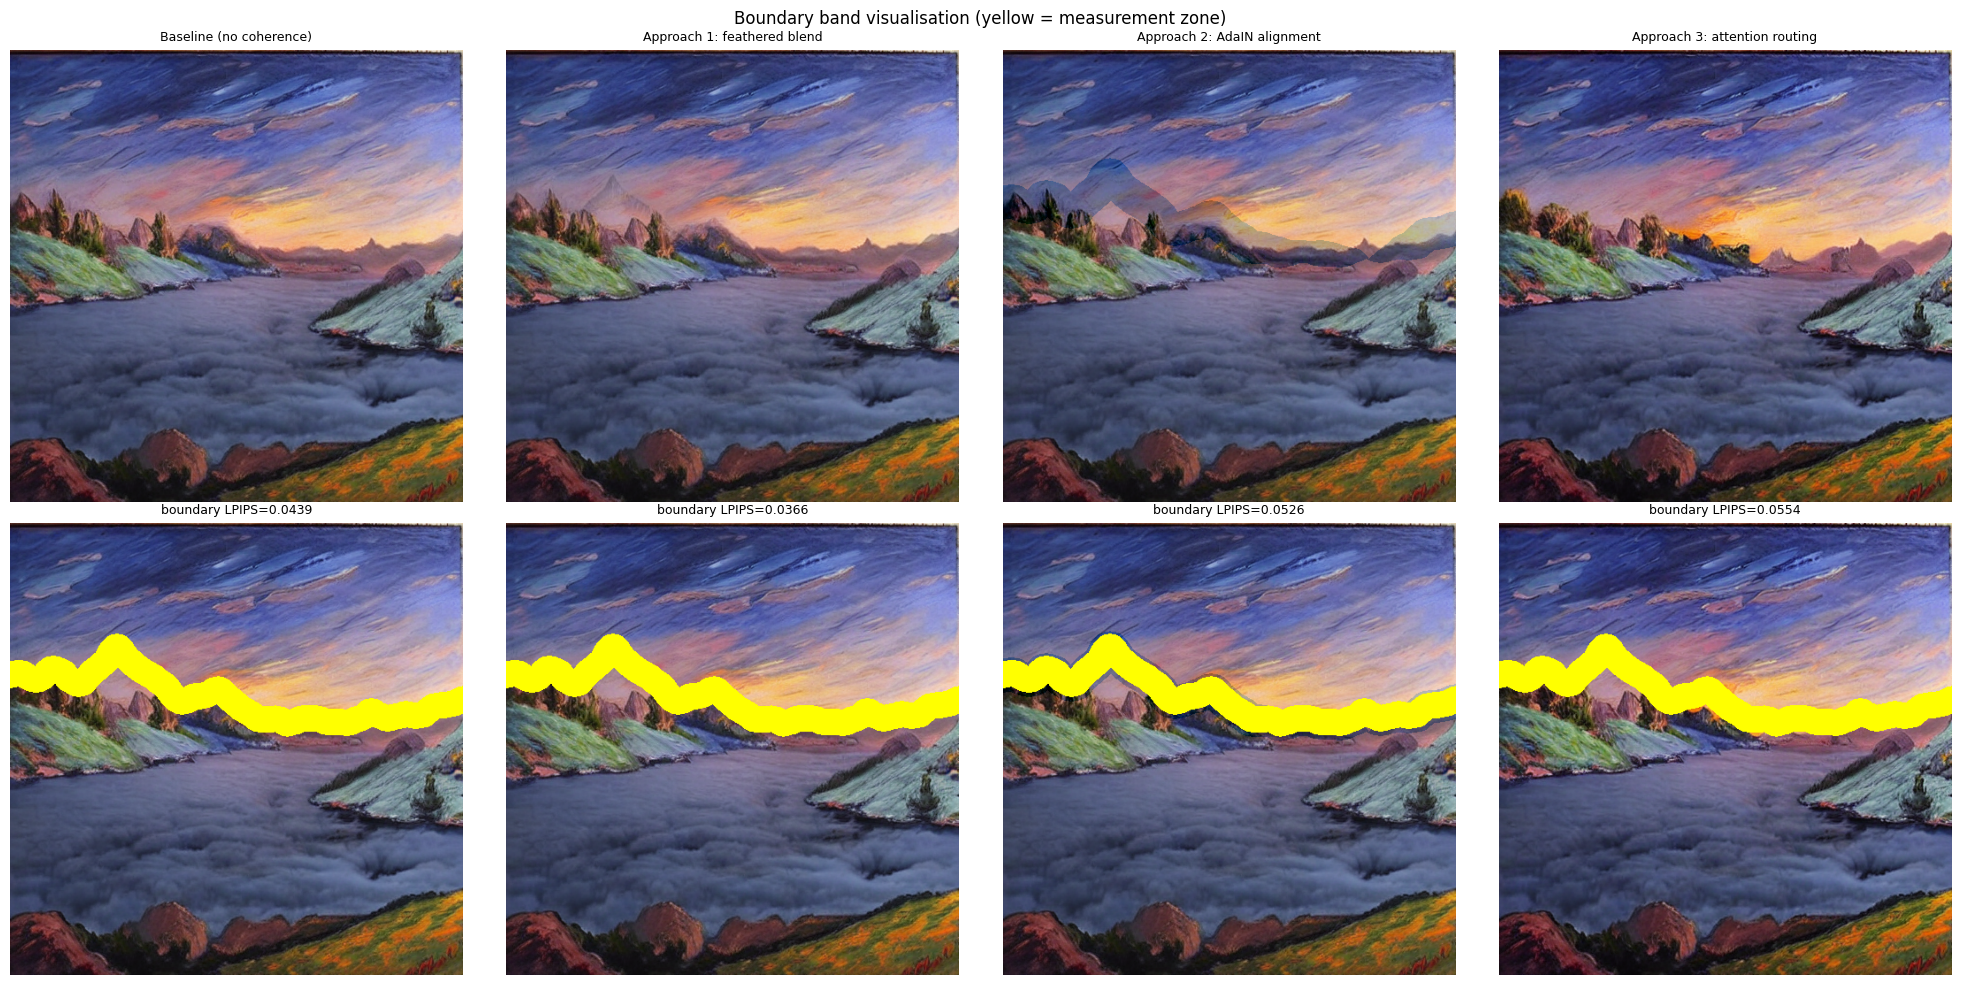

figures saved


In [14]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(content)
axes[0].set_title('Content')
axes[0].axis('off')

for i, (name, img) in enumerate(variants):
    score = results[i]['boundary_lpips']
    short = name.replace('Approach ', 'A').replace(': ', '\n')
    axes[i+1].imshow(img)
    axes[i+1].set_title(f'{short}\nLPIPS={score:.4f}', fontsize=9)
    axes[i+1].axis('off')

plt.suptitle('Boundary Coherence Ablation: IP-Adapter / SD1.5', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/boundary_ablation_comparison.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (name, img) in enumerate(variants):
    axes[0][i].imshow(img)
    axes[0][i].set_title(name, fontsize=9)
    axes[0][i].axis('off')
    axes[1][i].imshow(overlay_band(img, make_boundary_band(mask_sky)))
    axes[1][i].set_title(f'boundary LPIPS={results[i]["boundary_lpips"]:.4f}', fontsize=9)
    axes[1][i].axis('off')

plt.suptitle('Boundary band visualisation (yellow = measurement zone)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/boundary_band_all_variants.png', dpi=150)
plt.show()
print('figures saved')


In [12]:
summary = {
    'experiment':'boundary coherence ablation',
    'backbone':'SD1.5-Inpainting + IP-Adapter',
    'ip_scale':0.5,
    'results':results,
    'nst_reference': {
        'baseline':0.0678,
        'feathered':0.0529,
        'adain':0.0705,
        'cross_attn_nst': 0.0713,
    },
    'created_at': datetime.now().isoformat(),
}
with open(f'{OUT_DIR}/boundary_ablation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\n{"="*65}')
print(f'  SUMMARY')
print(f'{"="*65}')
for r in results:
    print(f'  {r["strategy"]:<35} {r["boundary_lpips"]:.4f}')
print(f'{"="*65}')
print(f'outputs saved to: {OUT_DIR}')



  SUMMARY
  Baseline (no coherence)             0.0439
  Approach 1: feathered blend         0.0366
  Approach 2: AdaIN alignment         0.0526
  Approach 3: attention routing       0.0554
outputs saved to: /homes/rkr44/mllm_style_transfer/boundary_ablation/outputs
